In [0]:
import requests
import pandas as pd

url = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.189/dados?formato=json&dataInicial=01/01/2015&dataFinal=31/12/2026"

resposta = requests.get(url)

df = pd.DataFrame(resposta.json())

df['data'] = pd.to_datetime(df['data'])

df['valor'] = pd.to_numeric(df['valor'])

df['ano'] = df['data'].dt.year

df['mes'] = df['data'].dt.month

print(resposta.status_code)
print(df.dtypes)
print(df.head(10))

200
data     datetime64[ns]
valor           float64
ano               int32
mes               int32
dtype: object
        data  valor   ano  mes
0 2015-01-01   0.76  2015    1
1 2015-01-02   0.27  2015    1
2 2015-01-03   0.98  2015    1
3 2015-01-04   1.17  2015    1
4 2015-01-05   0.41  2015    1
5 2015-01-06   0.67  2015    1
6 2015-01-07   0.69  2015    1
7 2015-01-08   0.28  2015    1
8 2015-01-09   0.95  2015    1
9 2015-01-10   1.89  2015    1


In [0]:
df_mensal = df.groupby(['ano', 'mes'])['valor'].mean().reset_index()
print(df_mensal.shape)
print(df_mensal.head(15))

(12, 3)
     ano  mes     valor
0   2015    1  0.840000
1   2016    1  0.581667
2   2017    1 -0.042500
3   2018    1  0.611667
4   2019    1  0.592500
5   2020    1  1.758333
6   2021    1  1.382500
7   2022    1  0.449167
8   2023    1 -0.265000
9   2024    1  0.530833
10  2025    1 -0.085000
11  2026    1  0.732500


In [0]:
url_mensal = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.189/dados/ultimos/20?formato=json"

resposta_teste = requests.get(url_mensal)
print(resposta_teste.status_code)
print(resposta_teste.json())

200
[{'data': '01/09/2024', 'valor': '0.62'}, {'data': '01/10/2024', 'valor': '1.52'}, {'data': '01/11/2024', 'valor': '1.30'}, {'data': '01/12/2024', 'valor': '0.94'}, {'data': '01/01/2025', 'valor': '0.27'}, {'data': '01/02/2025', 'valor': '1.06'}, {'data': '01/03/2025', 'valor': '-0.34'}, {'data': '01/04/2025', 'valor': '0.24'}, {'data': '01/05/2025', 'valor': '-0.49'}, {'data': '01/06/2025', 'valor': '-1.67'}, {'data': '01/07/2025', 'valor': '-0.77'}, {'data': '01/08/2025', 'valor': '0.36'}, {'data': '01/09/2025', 'valor': '0.42'}, {'data': '01/10/2025', 'valor': '-0.36'}, {'data': '01/11/2025', 'valor': '0.27'}, {'data': '01/12/2025', 'valor': '-0.01'}, {'data': '01/01/2026', 'valor': '0.41'}, {'data': '01/02/2026', 'valor': '-0.73'}, {'data': '01/03/2026', 'valor': '0.52'}, {'data': '01/04/2026', 'valor': '2.73'}]


In [0]:
url = "https://api.bcb.gov.br/dados/serie/bcdata.sgs.189/dados?formato=json&dataInicial=01/01/2015&dataFinal=31/12/2015"

resposta = requests.get(url)
print(resposta.json())

[{'data': '01/01/2015', 'valor': '0.76'}, {'data': '01/02/2015', 'valor': '0.27'}, {'data': '01/03/2015', 'valor': '0.98'}, {'data': '01/04/2015', 'valor': '1.17'}, {'data': '01/05/2015', 'valor': '0.41'}, {'data': '01/06/2015', 'valor': '0.67'}, {'data': '01/07/2015', 'valor': '0.69'}, {'data': '01/08/2015', 'valor': '0.28'}, {'data': '01/09/2015', 'valor': '0.95'}, {'data': '01/10/2015', 'valor': '1.89'}, {'data': '01/11/2015', 'valor': '1.52'}, {'data': '01/12/2015', 'valor': '0.49'}]


In [0]:
anos = range(2015, 2027)
lista_dfs = []

for ano in anos:
    # monta a url com o ano atual
    url = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.189/dados?formato=json&dataInicial=01/01/{ano}&dataFinal=31/12/{ano}"

    # faz a requisição
    resposta_teste_um = requests.get(url)
    df_ano = pd.DataFrame(resposta_teste_um.json())
    df_ano['data'] = pd.to_datetime(df_ano['data'], format='%d/%m/%Y')

    # adiciona à lista_dfs
    lista_dfs.append(df_ano)

df_completo = pd.concat(lista_dfs).reset_index(drop=True)
print(df_completo[df_completo['data'].dt.year == 2015]['data'])

0    2015-01-01
1    2015-02-01
2    2015-03-01
3    2015-04-01
4    2015-05-01
5    2015-06-01
6    2015-07-01
7    2015-08-01
8    2015-09-01
9    2015-10-01
10   2015-11-01
11   2015-12-01
Name: data, dtype: datetime64[ns]


In [0]:
df_completo['valor'] = pd.to_numeric(df_completo['valor'])
df_completo['ano'] = df_completo['data'].dt.year.astype(int)
df_completo['mes'] = df_completo['data'].dt.month.astype(int)
df_completo = df_completo.dropna(subset=['valor'])

print(df_completo.dtypes)
print(df_completo.shape)
print(df_completo['mes'].unique())

data     datetime64[ns]
valor           float64
ano               int64
mes               int64
dtype: object
(136, 4)
[ 1  2  3  4  5  6  7  8  9 10 11 12]


In [0]:
df_completo['data'] = pd.to_datetime(df_completo['data'], format='%d/%m/%Y')
df_completo['valor'] = pd.to_numeric(df_completo['valor'])
df_completo['ano'] = df_completo['data'].dt.year.astype(int)
df_completo['mes'] = df_completo['data'].dt.month.astype(int)

df_completo = df_completo.dropna(subset=['valor'])

print(df_completo.dtypes)
print(df_completo.head(15))
print(df_completo['mes'].unique())

print(df_completo['data'].unique())

print(df_completo[df_completo['ano'] == 2015]['data'])


data     datetime64[ns]
valor           float64
ano               int64
mes               int64
dtype: object
         data  valor   ano  mes
0  2015-01-01   0.76  2015    1
1  2015-02-01   0.27  2015    2
2  2015-03-01   0.98  2015    3
3  2015-04-01   1.17  2015    4
4  2015-05-01   0.41  2015    5
5  2015-06-01   0.67  2015    6
6  2015-07-01   0.69  2015    7
7  2015-08-01   0.28  2015    8
8  2015-09-01   0.95  2015    9
9  2015-10-01   1.89  2015   10
10 2015-11-01   1.52  2015   11
11 2015-12-01   0.49  2015   12
12 2016-01-01   1.14  2016    1
13 2016-02-01   1.29  2016    2
14 2016-03-01   0.51  2016    3
[ 1  2  3  4  5  6  7  8  9 10 11 12]
<DatetimeArray>
['2015-01-01 00:00:00', '2015-02-01 00:00:00', '2015-03-01 00:00:00',
 '2015-04-01 00:00:00', '2015-05-01 00:00:00', '2015-06-01 00:00:00',
 '2015-07-01 00:00:00', '2015-08-01 00:00:00', '2015-09-01 00:00:00',
 '2015-10-01 00:00:00',
 ...
 '2025-07-01 00:00:00', '2025-08-01 00:00:00', '2025-09-01 00:00:00',
 '2025-10-01 00

In [0]:
df_mensal = df_completo.groupby(['ano', 'mes'])['valor'].mean().reset_index()
df_mensal['data'] = pd.to_datetime(df_mensal.rename(columns={'ano': 'year', 'mes': 'month'}).assign(day=1)[['year', 'month', 'day']])

print(df_mensal.shape)
print(df_mensal.head(15))

(136, 4)
     ano  mes  valor       data
0   2015    1   0.76 2015-01-01
1   2015    2   0.27 2015-02-01
2   2015    3   0.98 2015-03-01
3   2015    4   1.17 2015-04-01
4   2015    5   0.41 2015-05-01
5   2015    6   0.67 2015-06-01
6   2015    7   0.69 2015-07-01
7   2015    8   0.28 2015-08-01
8   2015    9   0.95 2015-09-01
9   2015   10   1.89 2015-10-01
10  2015   11   1.52 2015-11-01
11  2015   12   0.49 2015-12-01
12  2016    1   1.14 2016-01-01
13  2016    2   1.29 2016-02-01
14  2016    3   0.51 2016-03-01


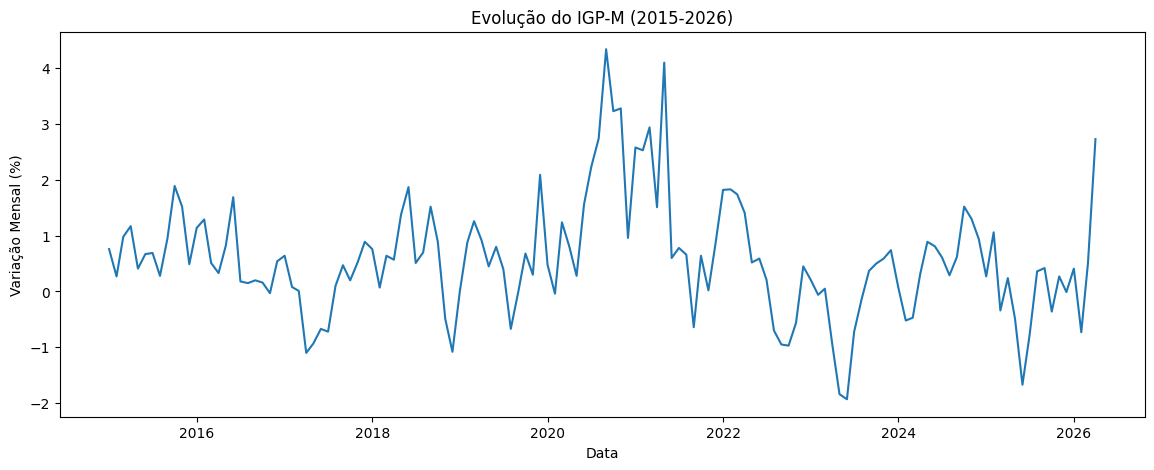

In [0]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))  # tamanho do gráfico
plt.plot(df_mensal['data'], df_mensal['valor']) # o que plotar
plt.title("Evolução do IGP-M (2015-2026)") # título
plt.xlabel("Data") # label eixo X
plt.ylabel("Variação Mensal (%)") # label eixo Y
plt.show() # mostrar o gráfico

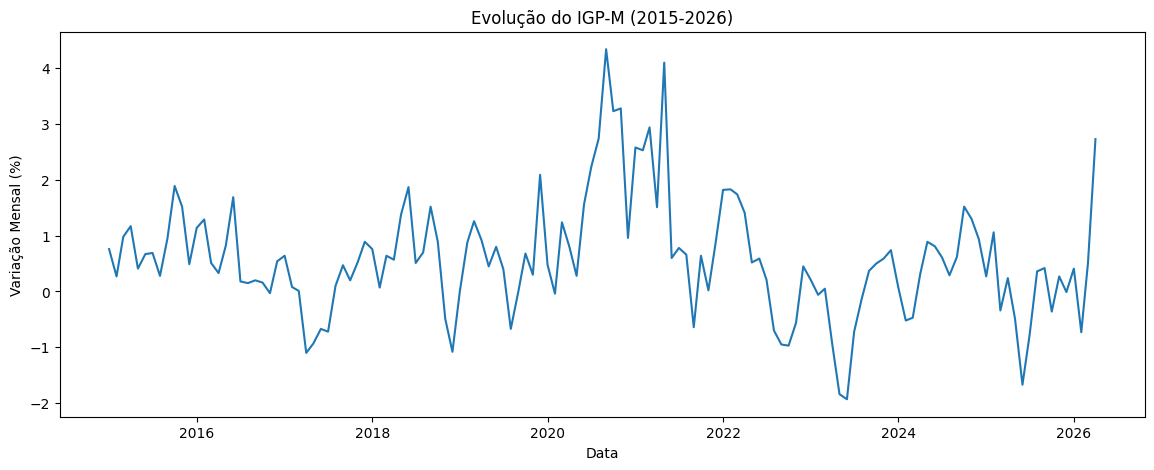

In [0]:
df_mensal['data'] = pd.to_datetime(df_mensal.rename(columns={'ano': 'year', 'mes': 'month'}).assign(day=1)[['year', 'month', 'day']])

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))  # tamanho do gráfico
plt.plot(df_mensal['data'], df_mensal['valor']) # o que plotar
plt.title("Evolução do IGP-M (2015-2026)") # título
plt.xlabel("Data") # label eixo X
plt.ylabel("Variação Mensal (%)") # label eixo Y
plt.show() # mostrar o gráfico

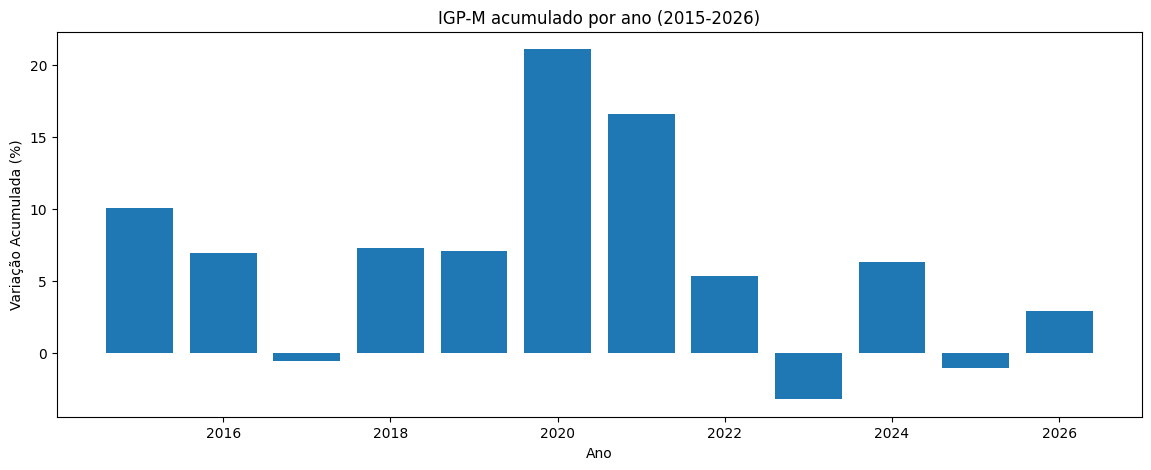

In [0]:
df_anual = df_mensal.groupby('ano')['valor'].sum().reset_index()

plt.figure(figsize=(14, 5))  # tamanho do gráfico
plt.bar(df_anual['ano'], df_anual['valor']) # o que plotar
plt.title("IGP-M acumulado por ano (2015-2026)") # título
plt.xlabel("Ano") # label eixo X
plt.ylabel("Variação Acumulada (%)") # label eixo Y
plt.show() # mostrar o gráfico

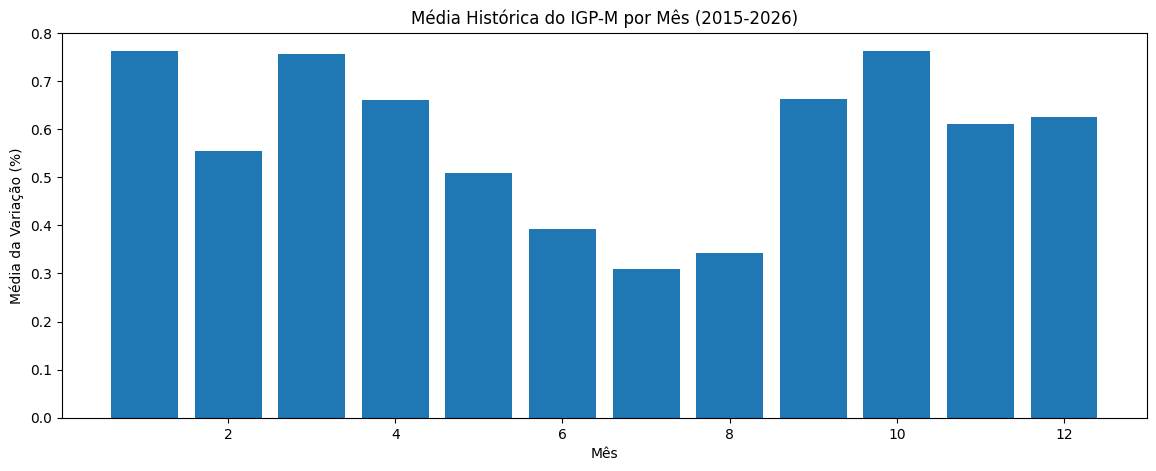

In [0]:

df_mes = df_mensal.groupby('mes')['valor'].mean().reset_index()

plt.figure(figsize=(14, 5))  # tamanho do gráfico
plt.bar(df_mes['mes'], df_mes['valor']) # o que plotar
plt.title("Média Histórica do IGP-M por Mês (2015-2026)") # título
plt.xlabel("Mês") # label eixo X
plt.ylabel("Média da Variação (%)") # label eixo Y
plt.show() # mostrar o gráfico

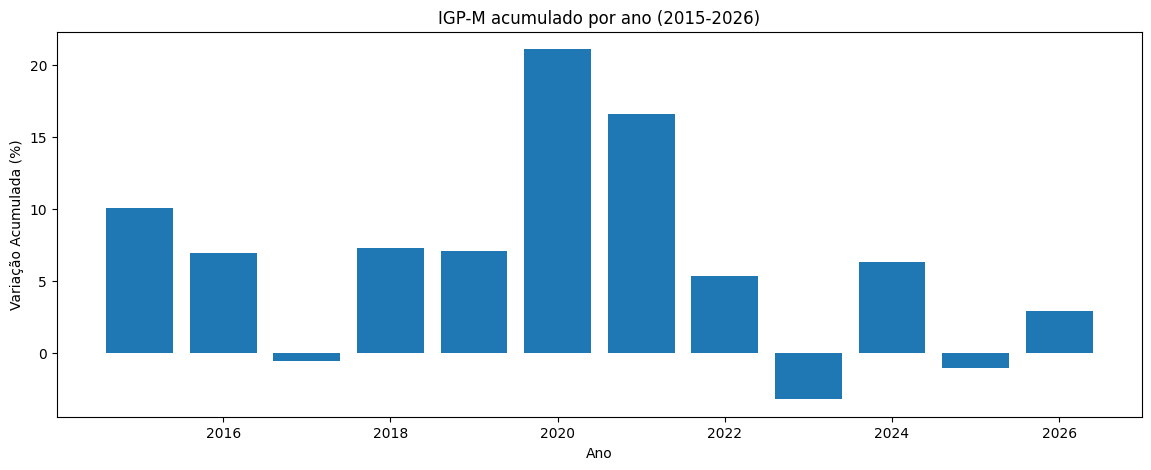

In [0]:
df_anual = df_mensal.groupby('ano')['valor'].sum().reset_index()


plt.figure(figsize=(14, 5))  # tamanho do gráfico
plt.bar(df_anual['ano'], df_anual['valor']) # o que plotar
plt.title("IGP-M acumulado por ano (2015-2026)") # título
plt.xlabel("Ano") # label eixo X
plt.ylabel("Variação Acumulada (%)") # label eixo Y
plt.show() # mostrar o gráfico

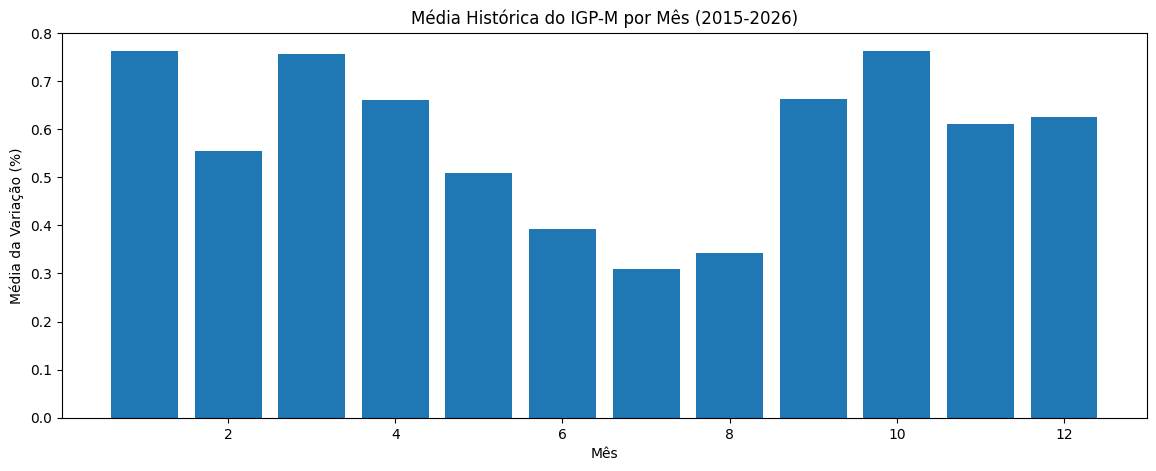

In [0]:

df_mes = df_mensal.groupby('mes')['valor'].mean().reset_index()

plt.figure(figsize=(14, 5))  # tamanho do gráfico
plt.bar(df_mes['mes'], df_mes['valor']) # o que plotar
plt.title("Média Histórica do IGP-M por Mês (2015-2026)") # título
plt.xlabel("Mês") # label eixo X
plt.ylabel("Média da Variação (%)") # label eixo Y
plt.show() # mostrar o gráfico

In [0]:
df_por_mes = df_mensal.groupby('mes')['valor'].mean().reset_index()
print(df_por_mes)

    mes     valor
0     1  0.762500
1     2  0.555000
2     3  0.756667
3     4  0.661667
4     5  0.508182
5     6  0.392727
6     7  0.309091
7     8  0.342727
8     9  0.662727
9    10  0.761818
10   11  0.610909
11   12  0.625455


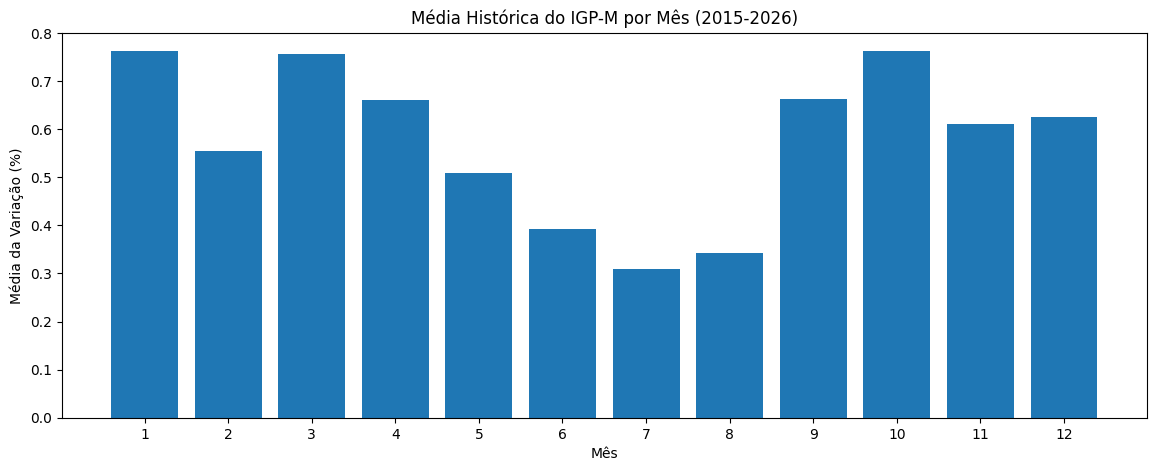

In [0]:
plt.figure(figsize=(14, 5))
plt.bar(df_por_mes['mes'], df_por_mes['valor'])
plt.title("Média Histórica do IGP-M por Mês (2015-2026)")
plt.xlabel("Mês")
plt.ylabel("Média da Variação (%)")
plt.xticks(range(1, 13))
plt.show()

In [0]:
df_spark = spark.createDataFrame(df_completo)
df_spark.show(5)

+-------------------+-----+----+---+
|               data|valor| ano|mes|
+-------------------+-----+----+---+
|2015-01-01 00:00:00| 0.76|2015|  1|
|2015-02-01 00:00:00| 0.27|2015|  2|
|2015-03-01 00:00:00| 0.98|2015|  3|
|2015-04-01 00:00:00| 1.17|2015|  4|
|2015-05-01 00:00:00| 0.41|2015|  5|
+-------------------+-----+----+---+
only showing top 5 rows


In [0]:
df_spark.write.format("delta").mode("overwrite").saveAsTable("igpm_historico")

In [0]:
%sql
SHOW TABLES

database,tableName,isTemporary
default,classificacao_ano,false
default,igpm_historico,false


In [0]:
df_completo.toPandas().to_csv('/dbfs/FileStore/igpm_historico.csv', index=False)

---------------------------------------------------------------------------
AttributeError                            Traceback (most recent call last)
~/.ipykernel/2058/command-5788880059664857-2989502469 in ?()
----> 1 df_completo.toPandas().to_csv('/dbfs/FileStore/igpm_historico.csv', index=False)

/databricks/python/lib/python3.12/site-packages/pandas/core/generic.py in ?(self, name)
   6295             and name not in self._accessors
   6296             and self._info_axis._can_hold_identifiers_and_holds_name(name)
   6297         ):
   6298             return self[name]
-> 6299         return object.__getattribute__(self, name)

AttributeError: 'DataFrame' object has no attribute 'toPandas'

In [0]:
df_completo.to_csv('/dbfs/FileStore/igpm_historico.csv', index=False)


---------------------------------------------------------------------------
OSError                                   Traceback (most recent call last)
File <command-5788880059664858>, line 1
----> 1 df_completo.to_csv('/dbfs/FileStore/igpm_historico.csv', index=False)

File /databricks/python/lib/python3.12/site-packages/pandas/util/_decorators.py:333, in deprecate_nonkeyword_arguments.<locals>.decorate.<locals>.wrapper(*args, **kwargs)
    327 if len(args) > num_allow_args:
    328     warnings.warn(
    329         msg.format(arguments=_format_argument_list(allow_args)),
    330         FutureWarning,
    331         stacklevel=find_stack_level(),
    332     )
--> 333 return func(*args, **kwargs)

File /databricks/python/lib/python3.12/site-packages/pandas/core/generic.py:3967, in NDFrame.to_csv(self, path_or_buf, sep, na_rep, float_format, columns, header, index, index_label, mode, encoding, compression, quoting, quotechar, lineterminator, chunksize, date_format, doublequote, esca

In [0]:
dbutils.fs.ls('dbfs:/FileStore/')


---------------------------------------------------------------------------
ExecutionError                            Traceback (most recent call last)
File <command-5788880059664859>, line 1
----> 1 dbutils.fs.ls('dbfs:/FileStore/')

File /databricks/python_shell/lib/dbruntime/remotefshandler/RemoteFsHandler.py:56, in prettify_exception_message.<locals>.f_with_exception_handling(*args, **kwargs)
     52     pass
     54 error_exception = ExecutionError(str(e))
---> 56 raise patch_exception_with_error_details(
     57     error_exception,
     58     DriverErrorCode.REMOTE_FS_HANDLER_EXECUTION_ERROR  # type: ignore[attr-defined]
     59 ) from None

ExecutionError: [DBFS_DISABLED] Public DBFS root is disabled. Access is denied on path: /FileStore SQLSTATE: 56038

JVM stacktrace:
com.databricks.backend.daemon.data.client.DbfsUnsupportedOperationSparkException
	at com.databricks.backend.daemon.data.client.DbfsExceptionMapperImpl.withExceptionWrapping(DbfsSparkException.scala:42)
	at com.